# 04 · A classical baseline — NMF + KMeans
### DINO-4DSTEM tutorials

Before trusting a deep model it helps to compare against a **classical,
interpretable** method. Here we cluster the same WS2 data with **Non-negative
Matrix Factorisation (NMF)** + **KMeans**, and compare it to DINO and the ground
truth. The comparison also shows *why* the rotation-invariant deep model wins.

## 1 · The math — NMF

Stack the $N$ diffraction patterns (flattened to length $D$) into a matrix
$V \in \mathbb{R}^{N\times D}_{\ge 0}$ (intensities are non-negative). NMF
approximates it as a product of two **non-negative** matrices:

$$V \;\approx\; W\,H, \qquad W \in \mathbb{R}^{N\times k}_{\ge 0},\; H \in \mathbb{R}^{k\times D}_{\ge 0}.$$

- The $k$ rows of $H$ are **basis patterns** ("components") — recurring
  diffraction motifs.
- Row $i$ of $W$ says **how much** of each component pattern $i$ contains — a
  $k$-dimensional fingerprint of that probe position.

It is fit by minimising $\lVert V - WH\rVert_F^2$ with multiplicative updates
that keep everything $\ge 0$. Non-negativity makes the parts **additive and
physically readable** (unlike PCA, which allows cancellation).

We then run **KMeans on the weight rows $W$** to group probe positions into
classes, and reshape those labels back onto the scan -> an NMF class map.

## 2 · Run NMF on the WS2 cube

We feed NMF the **polar** patterns (log-scaled) with a **$\theta$-shift
augmentation** — the fairest classical setup, giving NMF its best shot at the
in-plane rotations. We use `n_components = 6`, then cluster the weights **two
ways**:

- **`k = 3`** — forced to match the 3 ground-truth orientations, for a direct
  comparison;
- **auto-`k`** — the same method the GUI uses: scan `k` and pick the one with
  the best **silhouette** score.

In [1]:
import os, numpy as np
import ws2_utils as wu
wu.add_src_to_path(); wu.preimport()
import gui_app.nmf_panel as nmf          # importing this sets Agg; do it before inline
%matplotlib inline
import matplotlib.pyplot as plt
from data import register_runtime_sample

ex = wu.find_ws2_example()
cube_path = os.path.join(ex, 'phantom.cube.npy')
gt   = np.load(os.path.join(ex, 'phantom.classmap_main.npy'))
cube = np.load(cube_path, mmap_mode='r'); Ny, Nx = gt.shape
key = register_runtime_sample(cube_path, scan_shape=(Ny, Nx), vmax=50.0,
                              center_mask_radius=15)

In [2]:
# NMF:  V (patterns) ~= W (weights) x H (basis patterns)
X, X_aug, comp_shape, info = nmf.build_nmf_input(
    key, {'input': 'polar', 'log': True, 'theta_shift': True})
W, H, recon_err = nmf.fit_nmf(X, X_aug, n_components=6)

# cluster the weights two ways
nmf_map_k3 = nmf.cluster_W(W, 'kmeans', k=3).reshape(Ny, Nx)   # (a) fixed k=3
k_auto, sil = nmf.auto_K(W)                                    # (b) GUI silhouette scan
nmf_map_auto = nmf.cluster_W(W, 'kmeans', k=k_auto).reshape(Ny, Nx)
print(f'auto-k picked k = {k_auto}')

auto-k picked k = 10


### How auto-k chooses

The **silhouette score** measures how tightly grouped and well-separated the
clusters are. The GUI scans `k` and takes the peak. Notice it lands **well above
3** — silhouette rewards splitting each in-plane rotation into its own tight
cluster, so NMF's "natural" number of classes over-counts the real orientations.

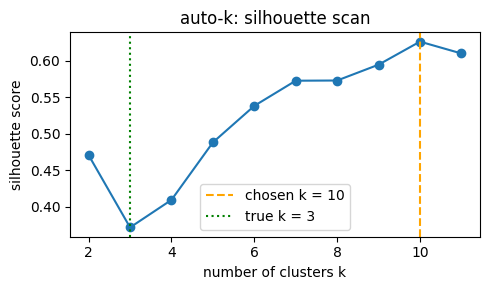

In [3]:
ks = np.arange(2, 2 + len(sil))
plt.figure(figsize=(5, 3))
plt.plot(ks, sil, 'o-')
plt.axvline(k_auto, color='orange', ls='--', label=f'chosen k = {k_auto}')
plt.axvline(3, color='green', ls=':', label='true k = 3')
plt.xlabel('number of clusters k'); plt.ylabel('silhouette score')
plt.legend(); plt.title('auto-k: silhouette scan'); plt.tight_layout(); plt.show()

### The other clustering methods

The GUI can cluster the NMF weights four ways — **KMeans**, **fuzzy c-means
(FCM)**, **agglomerative (aglo)**, and **HDBSCAN** (density-based, picks its own
number of clusters). Here they are, all at `k = 3` where applicable.

C:\Users\danielkh\AppData\Local\anaconda3\envs\py4DSTEM_SAM\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\danielkh\AppData\Local\anaconda3\envs\py4DSTEM_SAM\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


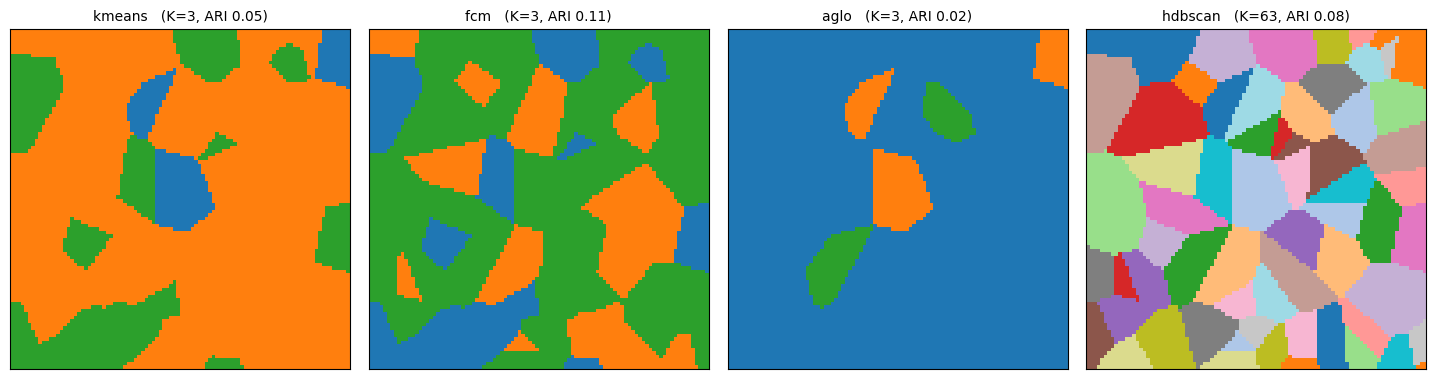

kmeans  : ARI 0.049   accuracy  41.9%   mean IoU 0.213
fcm     : ARI 0.111   accuracy  49.7%   mean IoU 0.309
aglo    : ARI 0.017   accuracy  42.3%   mean IoU 0.191
hdbscan : ARI 0.081   accuracy  10.4%   mean IoU 0.103


In [4]:
methods = ['kmeans', 'fcm', 'aglo', 'hdbscan']
maps, scores = {}, {}
for m in methods:
    lab = np.asarray(nmf.cluster_W(W, m, k=3))
    if (lab < 0).any():                       # HDBSCAN labels noise as -1
        lab = lab.copy(); lab[lab < 0] = lab.max() + 1   # -> its own cluster
    maps[m] = lab.reshape(Ny, Nx)
    scores[m] = wu.align_and_score(gt, maps[m])

fig, ax = plt.subplots(1, 4, figsize=(14.5, 3.7))
for a, m in zip(ax, methods):
    km = maps[m]; kk = int(km.max()) + 1
    a.imshow(km, cmap=wu.class_palette(kk), interpolation='nearest')
    a.set_title(f'{m}   (K={kk}, ARI {scores[m]["ARI"]:.2f})', fontsize=10)
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

for m in methods:
    print(f'{m:8s}: ARI {scores[m]["ARI"]:.3f}   accuracy {scores[m]["accuracy"]*100:5.1f}%   mean IoU {scores[m]["mean_IoU"]:.3f}')

**All four stay far below DINO.** FCM does best (~0.11 ARI) but still fails;
agglomerative and KMeans barely beat chance; HDBSCAN shatters the data into
dozens of tiny density clusters. The reason is the same for every method: NMF's
weights encode the **in-plane rotation**, so *no* clustering of them can recover
the 3 physical orientations. The rotation-invariant deep model can.

### The components NMF found

Each panel is one basis pattern (a row of $H$, back in polar coordinates). These
are the recurring motifs NMF built the data from.

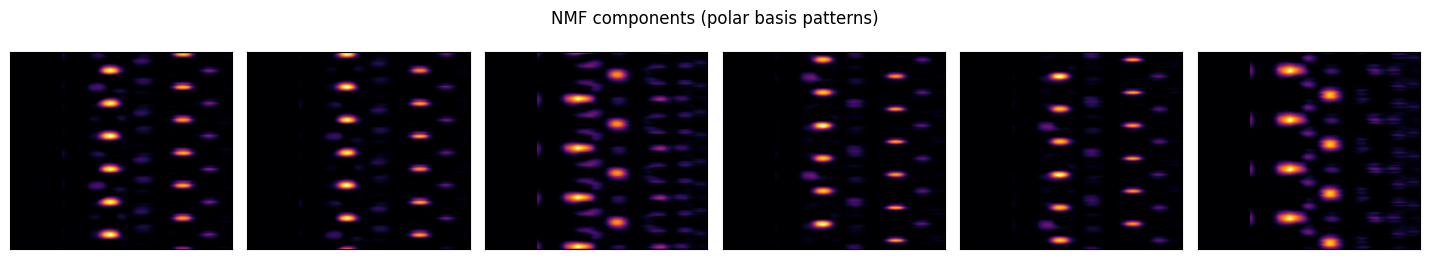

In [5]:
fig, ax = plt.subplots(1, H.shape[0], figsize=(2.4*H.shape[0], 2.6))
for a, h in zip(np.atleast_1d(ax), H):
    a.imshow(np.log1p(h.reshape(comp_shape)), cmap='inferno', aspect='auto')
    a.set_xticks([]); a.set_yticks([])
fig.suptitle('NMF components (polar basis patterns)'); plt.tight_layout(); plt.show()

## 3 · NMF vs ground truth

Same scoring as notebook 03: Hungarian-align the labels, then accuracy / ARI /
NMI / per-class IoU.

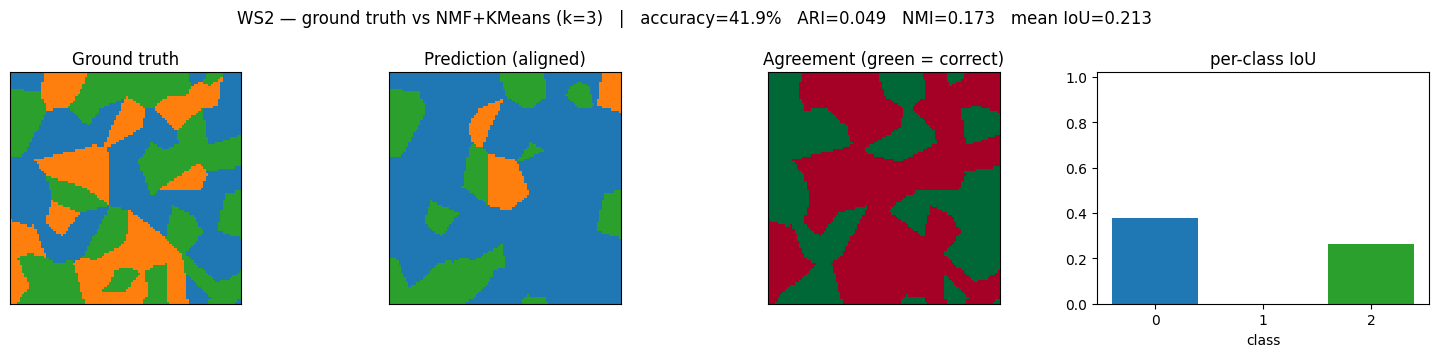

In [6]:
s_nmf_k3   = wu.align_and_score(gt, nmf_map_k3)     # forced k=3
s_nmf_auto = wu.align_and_score(gt, nmf_map_auto)   # auto-k (silhouette)
fig = wu.plot_gt_vs_pred(gt, s_nmf_k3, title='WS2 — ground truth vs NMF+KMeans (k=3)')
plt.show()

## 4 · DINO vs NMF vs ground truth

Below: the truth, DINO, and **both** NMF results — the fixed `k=3` map and the
auto-`k` (over-segmented) map.

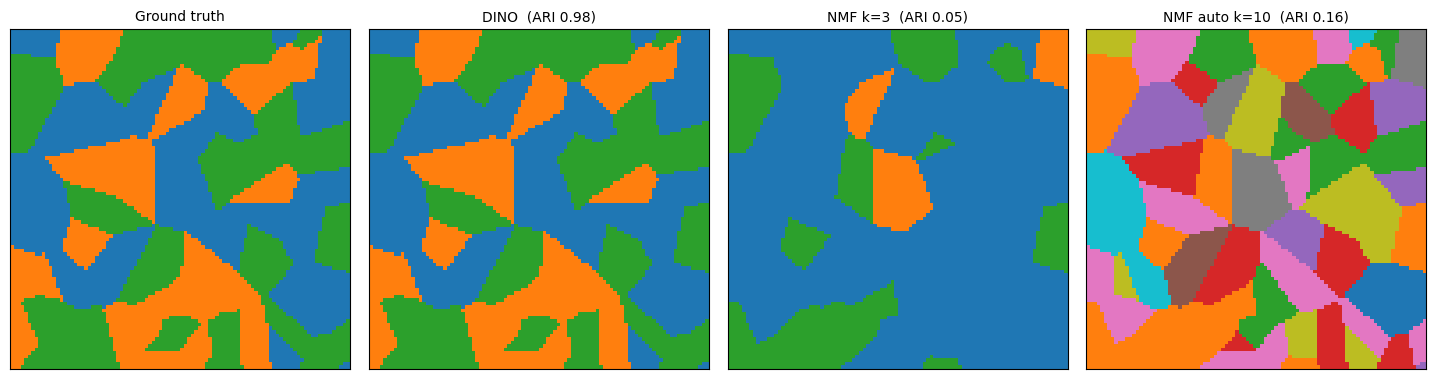

DINO        : accuracy  98.9%   ARI 0.982   mean IoU 0.990
NMF (k=3)   : accuracy  41.9%   ARI 0.049   mean IoU 0.213
NMF (auto,k=10): accuracy  28.4%   ARI 0.163   mean IoU 0.244


In [7]:
ck = wu.find_ws2_checkpoint()
dino = wu.run_dino_inference(cube_path, ck, scan_shape=(Ny, Nx), use_cache=True)
s_dino = wu.align_and_score(gt, dino['class_map'])

K = int(gt.max()) + 1
clip = lambda m: np.clip(m, 0, K - 1)     # map rare 'unassigned' (-1) -> class 0
# DINO and NMF(k=3) are aligned to the GT ids, so their colours match GT.
panels = [(gt, 'Ground truth', K),
          (clip(s_dino['pred_aligned']), f"DINO  (ARI {s_dino['ARI']:.2f})", K),
          (clip(s_nmf_k3['pred_aligned']), f"NMF k=3  (ARI {s_nmf_k3['ARI']:.2f})", K),
          (nmf_map_auto, f"NMF auto k={k_auto}  (ARI {s_nmf_auto['ARI']:.2f})",
           int(nmf_map_auto.max()) + 1)]
fig, ax = plt.subplots(1, 4, figsize=(14.5, 3.7))
for a, (m, t, kk) in zip(ax, panels):
    a.imshow(m, cmap=wu.class_palette(kk), vmin=-.5, vmax=kk - .5,
             interpolation='nearest')
    a.set_title(t, fontsize=10); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

print(f"DINO        : accuracy {s_dino['accuracy']*100:5.1f}%   ARI {s_dino['ARI']:.3f}   mean IoU {s_dino['mean_IoU']:.3f}")
print(f"NMF (k=3)   : accuracy {s_nmf_k3['accuracy']*100:5.1f}%   ARI {s_nmf_k3['ARI']:.3f}   mean IoU {s_nmf_k3['mean_IoU']:.3f}")
print(f"NMF (auto,k={k_auto}): accuracy {s_nmf_auto['accuracy']*100:5.1f}%   ARI {s_nmf_auto['ARI']:.3f}   mean IoU {s_nmf_auto['mean_IoU']:.3f}")

## 5 · Why does NMF underperform here?

NMF (and KMeans on its weights) is **not rotation-invariant**. In this phantom
every grain is spun to a *random in-plane angle*, so the same crystal orientation
appears as many different-looking patterns. NMF spends its components describing
those *rotations* rather than the *orientations*, so KMeans cannot collapse them
into the 3 true classes — it fragments and mixes them (low ARI). This is exactly
why **auto-k over-counts** (it chose k = 10 above, vs the true 3): the
silhouette score is
happiest splitting each rotation into its own cluster, not recovering the 3
physical orientations. Forcing `k = 3` doesn't fix it either — the classes are
tangled in NMF's weight space.

DINO wins because rotation invariance is **built into its design**: the polar
transform turns in-plane rotation into a $\theta$-shift, and the $\theta$-roll
augmentation trains the network to ignore it. That is the core reason the
self-supervised model recovers the orientations that the classical baseline
cannot.

> This is the honest picture: NMF is fast, interpretable, and a good sanity
> check, but for rotation-heavy data the rotation-invariant model is far more
> accurate.

### Done — end of the tutorial series

You've built a phantom (01), trained a self-supervised model (02), measured it
against the truth (03), and compared it to a classical baseline (04). The same
workflow applies to your own 4D-STEM data — just point the loaders at your file.